In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/models/harishs1729/checkpoint20/pytorch/default/1/flow_matching_mnist_epoch_20.pt
/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_4.npz
/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_3.npz
/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_0.npz
/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_1.npz
/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_2.npz


In [2]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import random

class MovingMNISTDataset(Dataset):
    def __init__(self, npz_path):
        # 1. Load the compressed numpy file
        data = np.load(npz_path)
        
        # .npz files contain multiple arrays accessed by keys. 
        # Usually, the main data is under 'arr_0', 'clips', or similar.
        key = data.files[0] 
        raw_videos = data[key]
        raw_videos = np.swapaxes(raw_videos, -2, -1)  
        self.videos = raw_videos.reshape(-1, 20, 64, 64)
        print(f"Loaded raw data shape: {self.videos.shape}")


    def __len__(self):
        return len(self.videos)

    def __getitem__(self, idx):
        # Extract the sequence: [Frames, H, W]
        video = self.videos[idx] 
        
        # Convert to PyTorch tensor
        tensor_video = torch.tensor(video, dtype=torch.float32)

        # cropping to 16 frames
        start_idx = random.randint(0, 4)
        tensor_video = tensor_video[start_idx:start_idx+16, :, :]
        
        # Add the Channel dimension required by Conv3d: [1, Frames, H, W]
        tensor_video = tensor_video.unsqueeze(0)
        
        # Normalize pixel values from [0, 255] to [-1, 1]. 
        # Neural networks and Flow Matching perform much better with zero-centered data.
        tensor_video = (tensor_video / 127.5) - 1.0
        
        return tensor_video

In [3]:
import torch.nn.functional as F
from torch.optim import AdamW

# --- Configuration ---
NPZ_PATH = '/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_4.npz'
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Setup Data ---
dataset = MovingMNISTDataset(NPZ_PATH)

Loaded raw data shape: (10000, 20, 64, 64)


Corrected Video Dataset Shape: (10000, 20, 1, 64, 64)


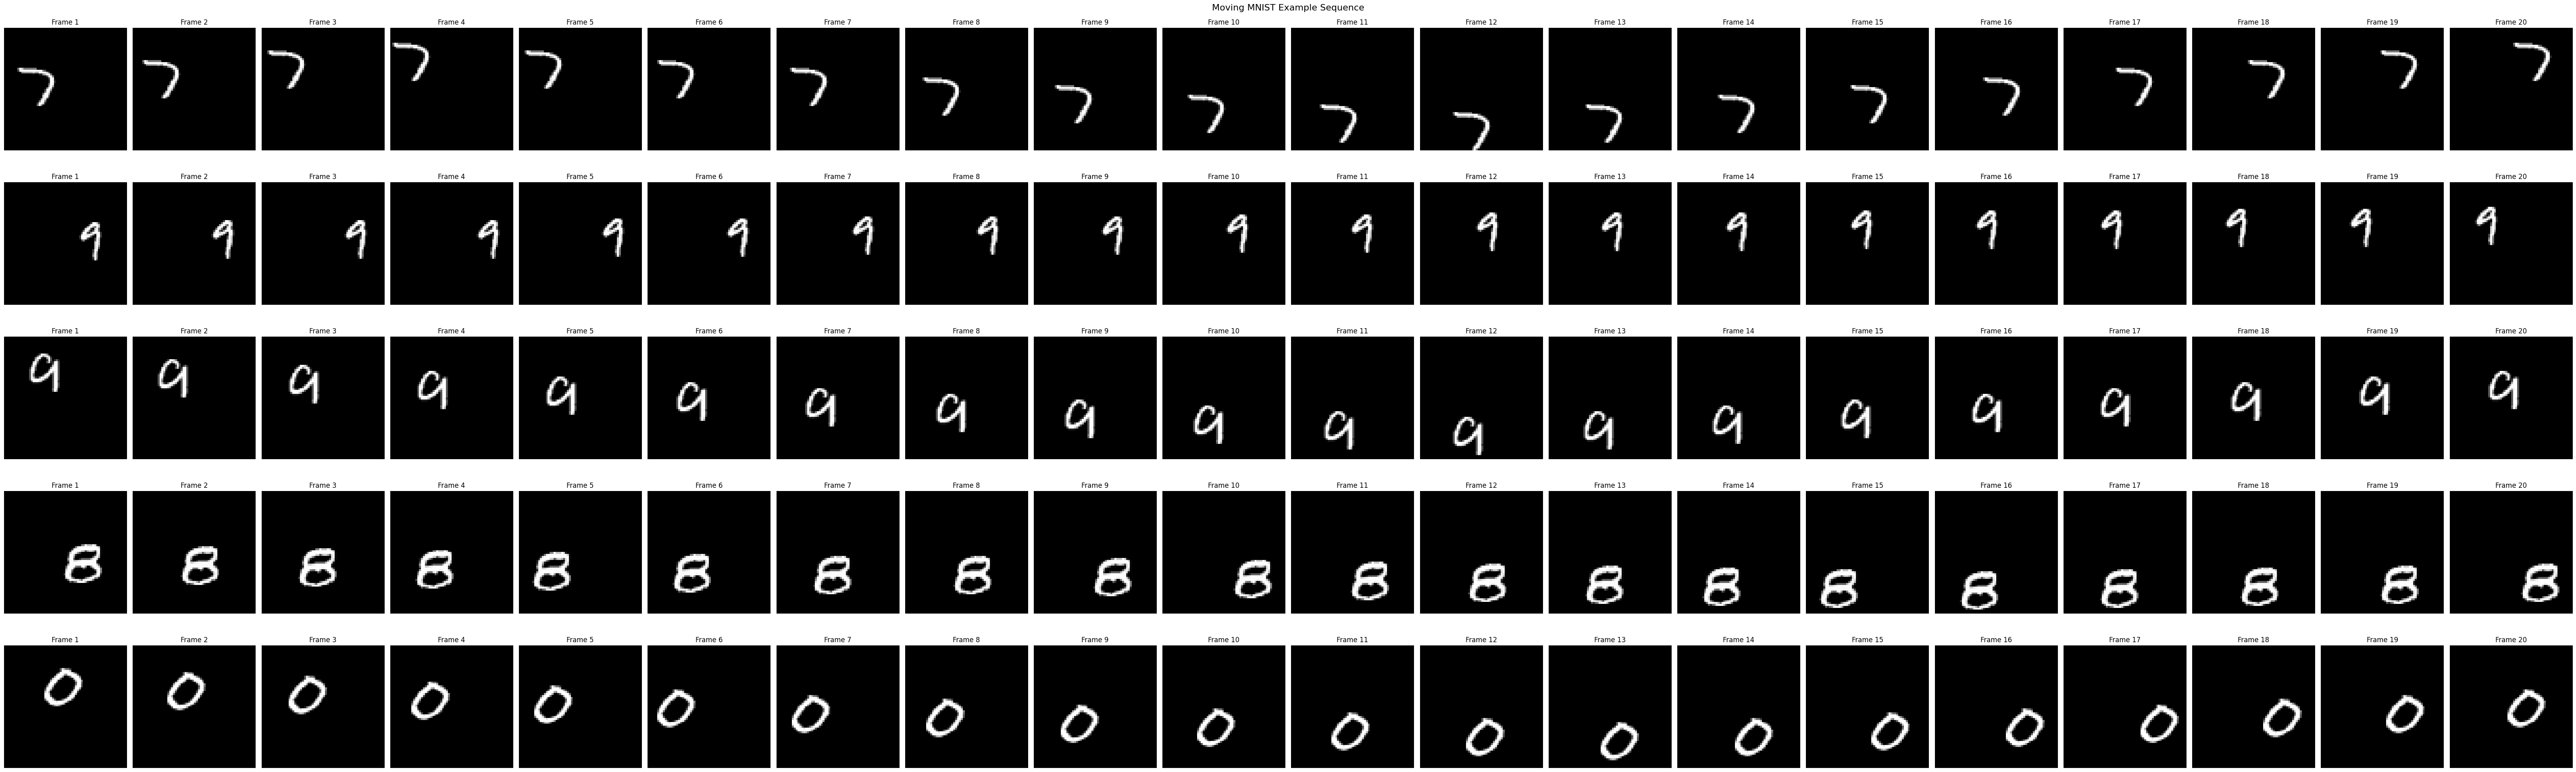

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

# 1. Load the raw data
data = np.load('/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_4.npz')
key = data.files[0]
raw_data = data[key]  # Shape: (200000, 1, 64, 64)

# 2. Reshape into videos
# We group every 4 consecutive frames into a single video sequence.
# New shape: (50000 videos, 4 frames, 1 channel, 64 height, 64 width)
raw_data = np.swapaxes(raw_data, -2, -1)
videos = raw_data.reshape(-1, 20, 1, 64, 64)
print(f"Corrected Video Dataset Shape: {videos.shape}")

# 3. Select an example video (let's grab the first one)
example_video = videos[0] # Shape: (4, 1, 64, 64)

# 4. Plot the frames side-by-side
fig, axes = plt.subplots(5, 20, figsize=(64, 20))
fig.suptitle("Moving MNIST Example Sequence", fontsize=16)

for j in range(5):
    example_video = videos[j+100] # Shape: (4, 1, 64, 64)
    for i in range(20):
        # Squeeze out the channel dimension so matplotlib can plot a 2D (64, 64) image
        frame = example_video[i].squeeze() 
        axes[j][i].imshow(frame, cmap='gray')
        axes[j][i].set_title(f"Frame {i+1}")
        axes[j][i].axis('off')

plt.tight_layout()
plt.show()

In [5]:
import math
import torch
import torch.nn as nn

class TimeEmbedding(nn.Module):
    """Converts a scalar timestep t into a high-dimensional positional embedding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        # t shape: [Batch]
        t = t * 1000.0 
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=t.device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block3D(nn.Module):
    """Standard 3D convolutional block with time embedding injection."""
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_channels)
        self.act1 = nn.SiLU()
        
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.act2 = nn.SiLU()
        
        # Projects the time embedding to match the channel dimension
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        )

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.act1(h)
        
        # Inject time: Reshape [B, C] to [B, C, 1, 1, 1] and add to feature map
        time_emb = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
        h = h + time_emb 
        
        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act2(h)
        return h

class UNet3D(nn.Module):
    """
    3D U-Net designed for Flow Matching on video sequences.
    Strictly preserves the temporal (frame) dimension throughout the network.
    """
    def __init__(self, in_channels=1, base_dim=32, time_emb_dim=128):
        super().__init__()
        
        # Time processing pipeline
        self.time_mlp = nn.Sequential(
            TimeEmbedding(base_dim),
            nn.Linear(base_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )
        
        # --- ENCODER ---
        self.down1 = Block3D(in_channels, base_dim, time_emb_dim)
        # kernel=(1, 2, 2) ensures Time dimension is untouched, only H and W are halved
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))
        
        self.down2 = Block3D(base_dim, base_dim * 2, time_emb_dim)
        self.pool2 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))
        
        # --- BOTTLENECK ---
        self.bottleneck = Block3D(base_dim * 2, base_dim * 2, time_emb_dim)
        
        # --- DECODER ---
        # scale_factor=(1, 2, 2) doubles H and W, leaves Time untouched
        self.up1 = nn.Upsample(scale_factor=(1, 2, 2), mode='nearest')
        # in_channels is base_dim * 4 because we concatenate [base_dim * 2] from up1 and [base_dim * 2] from down2
        self.up_block1 = Block3D(base_dim * 4, base_dim, time_emb_dim)
        
        self.up2 = nn.Upsample(scale_factor=(1, 2, 2), mode='nearest')
        # in_channels is base_dim * 2 because we concatenate [base_dim] from up2 and [base_dim] from down1
        self.up_block2 = Block3D(base_dim * 2, base_dim, time_emb_dim)
        
        # --- FINAL OUTPUT ---
        # Maps the features back to the original number of image channels (1 for Grayscale)
        self.final_conv = nn.Conv3d(base_dim, in_channels, kernel_size=3, padding=1)

    def forward(self, x, t):
        # 1. Process time scalar into embeddings
        t_emb = self.time_mlp(t)
        
        # 2. Encoder Pass
        d1 = self.down1(x, t_emb)
        p1 = self.pool1(d1)
        
        d2 = self.down2(p1, t_emb)
        p2 = self.pool2(d2)
        
        # 3. Bottleneck Pass
        b = self.bottleneck(p2, t_emb)
        
        # 4. Decoder Pass (with Skip Connections)
        u1 = self.up1(b)
        u1 = torch.cat([u1, d2], dim=1) # Skip connection 1
        u1 = self.up_block1(u1, t_emb)
        
        u2 = self.up2(u1)
        u2 = torch.cat([u2, d1], dim=1) # Skip connection 2
        u2 = self.up_block2(u2, t_emb)
        
        # 5. Output Predicted Vector Field
        out = self.final_conv(u2)
        return out

In [6]:
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import DataLoader

# ==========================================
# 1. Hyperparameters & Setup
# ==========================================
NPZ_PATH = '/kaggle/input/datasets/hughiephan/moving-mnist/mnist_1d64_4.npz'
BATCH_SIZE = 8  # Start with 8 to protect your GPU VRAM
LEARNING_RATE = 2e-4
EPOCHS = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Training on device: {DEVICE}")

# Initialize Dataset and Dataloader
# (Assuming the MovingMNISTDataset class from Phase 1 is defined above)
dataset = MovingMNISTDataset(NPZ_PATH)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Initialize Model and Optimizer
# (Assuming the SimpleUNet3D class from Phase 2 is defined above)
model = UNet3D(in_channels=1).to(DEVICE)
if torch.cuda.device_count() > 1:
    print(f"Awesome! Let's use {torch.cuda.device_count()} GPUs!")
    # Wrap the model in DataParallel
    model = torch.nn.DataParallel(model)

# Initialize Optimizer (Make sure this happens AFTER the DataParallel wrap)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# ==========================================
# 2. The Training Loop
# ==========================================
model.train()

for epoch in range(EPOCHS):
    total_loss = 0.0
    
    for batch_idx, x_1 in enumerate(dataloader):
        # x_1 is our target video: [Batch, 1, 16, 64, 64]
        x_1 = x_1.to(DEVICE) 
        batch_size = x_1.shape[0]
        
        optimizer.zero_grad()
        
        # --- THE CORE MATH ---
        
        # 1. Sample standard Gaussian noise (x_0)
        # Must perfectly match the target video shape
        x_0 = torch.randn_like(x_1) 
        
        # 2. Sample random timesteps (t)
        # Uniformly sample a time t between 0 and 1 for each video in the batch.
        # Shape t as [B, 1, 1, 1, 1] so it can broadcast against the 5D video tensors.
        t = torch.rand(batch_size, 1, 1, 1, 1, device=DEVICE)
        
        # 3. Calculate the interpolated state (x_t)
        # This is where the video currently is on its straight-line journey from noise to reality.
        x_t = (1 - t) * x_0 + t * x_1
        
        # 4. Calculate the target vector field (u_t)
        # The true direction the model should be pointing to reach x_1 from x_0.
        u_t = x_1 - x_0
        
        # --- NEURAL NETWORK PASS ---
        
        # 5. Predict the vector field
        # We must squeeze t down to [B] so the TimeEmbedding layer can process it.
        t_squeezed = t.squeeze() 
        v_pred = model(x_t, t_squeezed) 
        
        # 6. Calculate Loss and Optimize
        # Simple Mean Squared Error between what the model guessed and the true straight line.
        loss = F.mse_loss(v_pred, u_t)
        
        loss.backward()
        
        # Optional but highly recommended: Gradient Clipping stabilizes training
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        
        # ==========================================
        # 3. Logging
        # ==========================================
        if batch_idx % 50 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Batch {batch_idx}/{len(dataloader)} | Loss: {loss.item():.4f}")
            
    avg_loss = total_loss / len(dataloader)
    print(f"==> End of Epoch {epoch+1} | Average Loss: {avg_loss:.4f}\n")
    
    # Save a checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"flow_matching_mnist_epoch_{epoch+1}.pt")
        print(f"Saved checkpoint: flow_matching_mnist_epoch_{epoch+1}.pt")

Training on device: cuda
Loaded raw data shape: (10000, 20, 64, 64)
Awesome! Let's use 2 GPUs!
Epoch 1/50 | Batch 0/1250 | Loss: 2.3081
Epoch 1/50 | Batch 50/1250 | Loss: 0.1888
Epoch 1/50 | Batch 100/1250 | Loss: 0.1324
Epoch 1/50 | Batch 150/1250 | Loss: 0.1160
Epoch 1/50 | Batch 200/1250 | Loss: 0.1102
Epoch 1/50 | Batch 250/1250 | Loss: 0.1007
Epoch 1/50 | Batch 300/1250 | Loss: 0.0828
Epoch 1/50 | Batch 350/1250 | Loss: 0.0918
Epoch 1/50 | Batch 400/1250 | Loss: 0.1936
Epoch 1/50 | Batch 450/1250 | Loss: 0.0830
Epoch 1/50 | Batch 500/1250 | Loss: 0.0723
Epoch 1/50 | Batch 550/1250 | Loss: 0.0749
Epoch 1/50 | Batch 600/1250 | Loss: 0.0658
Epoch 1/50 | Batch 650/1250 | Loss: 0.0760
Epoch 1/50 | Batch 700/1250 | Loss: 0.0936
Epoch 1/50 | Batch 750/1250 | Loss: 0.0773
Epoch 1/50 | Batch 800/1250 | Loss: 0.0747
Epoch 1/50 | Batch 850/1250 | Loss: 0.0665
Epoch 1/50 | Batch 900/1250 | Loss: 0.0731
Epoch 1/50 | Batch 950/1250 | Loss: 0.0643
Epoch 1/50 | Batch 1000/1250 | Loss: 0.0670
Epoc

KeyboardInterrupt: 

Starting Euler ODE Solver on cuda...
Integration complete! Plotting generation steps...


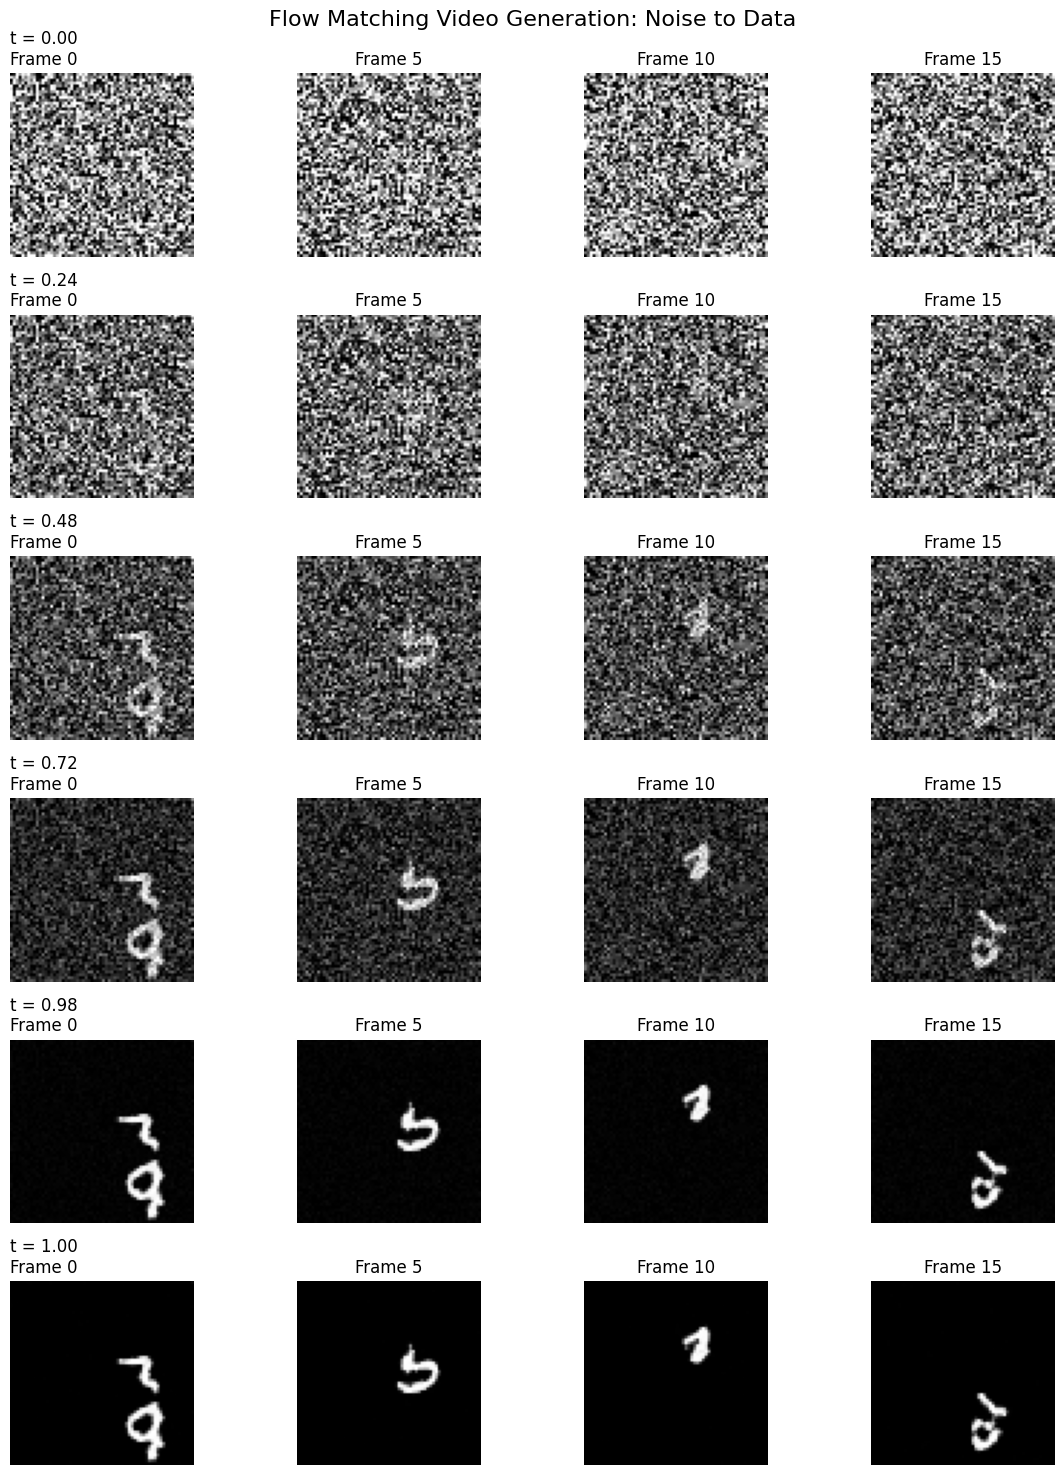

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import imageio

# ==========================================
# 1. Setup & Load Model
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = "/kaggle/working/flow_matching_mnist_epoch_40.pt" 
NUM_STEPS = 50 

model = UNet3D(in_channels=1).to(DEVICE)
# 2. Load the raw dictionary from the checkpoint
state_dict = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

# 3. Strip the "module." prefix created by DataParallel
cleaned_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}

# 4. Load the cleaned weights into the model
model.load_state_dict(cleaned_state_dict)
model.eval()

# ==========================================
# 2. The Euler Integration Loop (With Memory)
# ==========================================
x = torch.randn(1, 1, 16, 64, 64, device=DEVICE)
dt = 1.0 / NUM_STEPS

# We will store the state of the video at 5 specific steps
# Step 0, Step 12, Step 25, Step 37, Step 50
capture_intervals = np.linspace(0, NUM_STEPS - 1, 5, dtype=int)
captured_states = []
captured_times = []

print(f"Starting Euler ODE Solver on {DEVICE}...")

with torch.no_grad():
    for i in range(NUM_STEPS):
        t_val = i * dt
        t_tensor = torch.full((1,), t_val, device=DEVICE)
        
        # Save the current state if it matches our intervals
        if i in capture_intervals:
            # Move to CPU, denormalize to [0, 1], and save
            current_x = ((x.clone().squeeze().cpu().numpy() + 1.0) / 2.0)
            current_x = np.clip(current_x, 0.0, 1.0)
            captured_states.append(current_x)
            captured_times.append(t_val)
            
        v = model(x, t_tensor)
        x = x + v * dt

# Capture the final state at exactly t=1.0
final_x = ((x.squeeze().cpu().numpy() + 1.0) / 2.0)
final_x = np.clip(final_x, 0.0, 1.0)
captured_states.append(final_x)
captured_times.append(1.0)

print("Integration complete! Plotting generation steps...")

# ==========================================
# 3. Plotting the Evolution Grid
# ==========================================
# We will look at 4 specific frames from the 16-frame sequence
frames_to_show = [0, 5, 10, 15] 
num_snapshots = len(captured_states)

fig, axes = plt.subplots(num_snapshots, len(frames_to_show), figsize=(12, 2.5 * num_snapshots))
fig.suptitle("Flow Matching Video Generation: Noise to Data", fontsize=16)

for row_idx, state in enumerate(captured_states):
    t_val = captured_times[row_idx]
    
    for col_idx, frame_idx in enumerate(frames_to_show):
        ax = axes[row_idx, col_idx]
        
        # state shape is [16, 64, 64]. We grab the specific frame.
        img = state[frame_idx] 
        
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        
        # Add row labels (Time t)
        if col_idx == 0:
            ax.set_title(f"t = {t_val:.2f}\nFrame {frame_idx}", loc='left')
        else:
            ax.set_title(f"Frame {frame_idx}")

plt.tight_layout()
plt.show()
